In [1]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
from dataclasses import dataclass
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# 5-point Generator

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

plt.rcParams["figure.figsize"] = (7, 5)

Device: cpu


In [3]:
@dataclass
class StructuredGrid2D:
    nx: int
    ny: int
    lx: float
    ly: float
    thickness: float

    def __post_init__(self):
        self.n_cells = self.nx * self.ny
        self.dx = self.lx / self.nx
        self.dy = self.ly / self.ny
        self.bulk_volume = self.dx * self.dy * self.thickness
        self.face_i, self.face_j, self.face_area, self.face_distance = self._build_connectivity()
        self.cell_centers = self._build_centers()

    def cell_index(self, i, j):
        return i + self.nx * j

    def _build_centers(self):
        centers = np.zeros((self.n_cells, 2))
        for j in range(self.ny):
            for i in range(self.nx):
                c = self.cell_index(i, j)
                centers[c, 0] = (i + 0.5) * self.dx
                centers[c, 1] = (j + 0.5) * self.dy
        return centers

    def _build_connectivity(self):
        fi, fj, area, dist = [], [], [], []
        for j in range(self.ny):
            for i in range(self.nx):
                c = self.cell_index(i, j)
                if i + 1 < self.nx:
                    fi.append(c)
                    fj.append(self.cell_index(i + 1, j))
                    area.append(self.dy * self.thickness)
                    dist.append(self.dx)
                if j + 1 < self.ny:
                    fi.append(c)
                    fj.append(self.cell_index(i, j + 1))
                    area.append(self.dx * self.thickness)
                    dist.append(self.dy)
        return np.array(fi), np.array(fj), np.array(area, float), np.array(dist, float)

    def reshape(self, field):
        return np.asarray(field).reshape(self.ny, self.nx)


In [4]:
@dataclass
class CoreyFluid:
    mu_w: float = 1e-3
    mu_o: float = 4e-3
    s_wr: float = 0.20
    s_or: float = 0.25
    krw0: float = 0.30
    kro0: float = 1.00
    n_w: float = 2.0
    n_o: float = 2.0

    @property
    def s_min(self):
        return self.s_wr

    @property
    def s_max(self):
        return 1.0 - self.s_or

    def effective_saturation(self, sw):
        swe = (sw - self.s_wr) / (1.0 - self.s_wr - self.s_or)
        return np.clip(swe, 0.0, 1.0)

    def mobilities(self, sw):
        swe = self.effective_saturation(sw)
        krw = self.krw0 * swe ** self.n_w
        kro = self.kro0 * (1.0 - swe) ** self.n_o
        lam_w = krw / self.mu_w
        lam_o = kro / self.mu_o
        lam_t = lam_w + lam_o
        fw = lam_w / (lam_t + 1e-30)
        return lam_w, lam_o, lam_t, fw


class IMPES2D:
    def __init__(self, grid, phi=0.01, perm_mD=1.0):
        self.grid = grid
        self.phi = phi
        self.perm = perm_mD * 9.869233e-16
        self.fi = grid.face_i
        self.fj = grid.face_j
        self.T_geom = self.perm * grid.face_area / grid.face_distance

        self.rows_pattern = np.concatenate([self.fi, self.fj, np.arange(grid.n_cells)])
        self.cols_pattern = np.concatenate([self.fj, self.fi, np.arange(grid.n_cells)])

        self.inj = grid.cell_index(0, 0)
        self.prod = grid.cell_index(grid.nx - 1, grid.ny - 1)

        year = 365.0 * 24.0 * 3600.0
        pore_volume = phi * grid.lx * grid.ly * grid.thickness
        self.q_inj = 0.1 * pore_volume / year

        self.q_total = np.zeros(grid.n_cells)
        self.q_total[self.inj] = self.q_inj
        self.q_total[self.prod] = -self.q_inj
        self.gauge_cell = self.prod

    def pressure_solve(self, sw, fluid):
        _, _, lam_t, fw = fluid.mobilities(sw)
        lt_i = lam_t[self.fi]
        lt_j = lam_t[self.fj]
        lt_face = 2.0 * lt_i * lt_j / (lt_i + lt_j + 1e-30)
        T_face = self.T_geom * lt_face

        diag = np.zeros(self.grid.n_cells)
        np.add.at(diag, self.fi, T_face)
        np.add.at(diag, self.fj, T_face)

        data = np.concatenate([-T_face, -T_face, diag])
        A = sp.csr_matrix((data, (self.rows_pattern, self.cols_pattern)), shape=(self.grid.n_cells, self.grid.n_cells)).tolil()
        b = self.q_total.copy()

        # Gauge condition for no-flow pressure equation
        A[self.gauge_cell, :] = 0.0
        A[self.gauge_cell, self.gauge_cell] = 1.0
        b[self.gauge_cell] = 0.0

        p = spla.spsolve(A.tocsc(), b)
        F_total = -T_face * (p[self.fj] - p[self.fi])
        return p, F_total, fw

    def cfl_dt(self, F_total, cfl=0.5):
        outflux = np.zeros(self.grid.n_cells)
        np.add.at(outflux, self.fi, np.maximum(F_total, 0.0))
        np.add.at(outflux, self.fj, np.maximum(-F_total, 0.0))
        outflux += np.maximum(-self.q_total, 0.0)
        pv = self.phi * self.grid.bulk_volume
        return float(np.min(cfl * pv / np.maximum(outflux, 1e-30)))

    def transport_step(self, sw, F_total, fw, fluid, dt):
        upwind = np.where(F_total >= 0.0, self.fi, self.fj)
        Fw = fw[upwind] * F_total

        div = np.zeros(self.grid.n_cells)
        np.add.at(div, self.fi, Fw)
        np.add.at(div, self.fj, -Fw)

        q_w = np.zeros(self.grid.n_cells)
        q_w[self.inj] = self.q_inj
        q_w[self.prod] = fw[self.prod] * (-self.q_inj)

        pv = self.phi * self.grid.bulk_volume
        sw_new = sw + dt / pv * (q_w - div)
        return np.clip(sw_new, fluid.s_min, fluid.s_max)

    def run(self, n_w=2.0, n_o=2.0, final_years=20.0, n_save=41, cfl=0.5, max_dt_days=30.0):
        year = 365.0 * 24.0 * 3600.0
        final_time = final_years * year
        save_times = np.linspace(0.0, final_time, n_save)

        fluid = CoreyFluid(n_w=n_w, n_o=n_o)
        sw = np.full(self.grid.n_cells, fluid.s_min)

        saved_t, saved_sw, saved_p = [], [], []

        t = 0.0
        next_save = 0

        while next_save < len(save_times):
            target = save_times[next_save]
            while t < target - 1e-9:
                p, F, fw = self.pressure_solve(sw, fluid)
                dt = self.cfl_dt(F, cfl=cfl)
                dt = min(dt, max_dt_days * 86400.0, target - t)
                sw = self.transport_step(sw, F, fw, fluid, dt)
                t += dt

            p, F, fw = self.pressure_solve(sw, fluid)
            saved_t.append(t)
            saved_sw.append(sw.copy())
            saved_p.append(p.copy())
            next_save += 1

        return {
            "times": np.asarray(saved_t),
            "saturation": np.asarray(saved_sw),
            "pressure": np.asarray(saved_p),
            "n_w": n_w,
            "n_o": n_o,
        }

In [5]:
grid = StructuredGrid2D(nx=30, ny=30, lx=500.0, ly=500.0, thickness=50.0)
sim = IMPES2D(grid, phi=0.01, perm_mD=1.0)

param_train = [
    (2.0, 2.0),
    (2.0, 3.0),
    (3.0, 2.0),
    (3.0, 3.0),
    (4.0, 2.5),
    (2.5, 4.0),
]

solutions = []
for nw, no in param_train:
    print(f"Generating FV solution for n_w={nw}, n_o={no}")
    solutions.append(sim.run(n_w=nw, n_o=no, final_years=20.0, n_save=41))

print("Data generation finished.")

Generating FV solution for n_w=2.0, n_o=2.0
Generating FV solution for n_w=2.0, n_o=3.0
Generating FV solution for n_w=3.0, n_o=2.0
Generating FV solution for n_w=3.0, n_o=3.0
Generating FV solution for n_w=4.0, n_o=2.5
Generating FV solution for n_w=2.5, n_o=4.0
Data generation finished.


In [6]:
def build_dataset(solutions, grid, max_points_per_solution=25000):
    X_list, Y_list = [], []
    centers = grid.cell_centers
    x = centers[:, 0] / grid.lx
    y = centers[:, 1] / grid.ly
    T_final = 20.0 * 365.0 * 24.0 * 3600.0

    global_p_scale = max(max(np.max(np.abs(sol["pressure"])) for sol in solutions), 1.0)

    for sol in solutions:
        times = sol["times"]
        Sw = sol["saturation"]
        P = sol["pressure"] / global_p_scale

        X_sol, Y_sol = [], []
        for it, t in enumerate(times):
            nc = grid.n_cells
            X = np.stack([
                x,
                y,
                np.full(nc, t / T_final),
                np.full(nc, sol["n_w"]),
                np.full(nc, sol["n_o"]),
            ], axis=1)
            Y = np.stack([Sw[it], P[it]], axis=1)
            X_sol.append(X)
            Y_sol.append(Y)

        X_sol = np.vstack(X_sol)
        Y_sol = np.vstack(Y_sol)

        if len(X_sol) > max_points_per_solution:
            idx = np.random.choice(len(X_sol), max_points_per_solution, replace=False)
            X_sol = X_sol[idx]
            Y_sol = Y_sol[idx]

        X_list.append(X_sol)
        Y_list.append(Y_sol)

    X = np.vstack(X_list).astype(np.float32)
    Y = np.vstack(Y_list).astype(np.float32)

    return X, Y, global_p_scale

X, Y, pressure_scale = build_dataset(solutions, grid)
print("Dataset:", X.shape, Y.shape)
print("Pressure scale:", pressure_scale)

Dataset: (150000, 5) (150000, 2)
Pressure scale: 347715328.58612955


# Net part

In [7]:
# Normalize parameter inputs n_w,n_o to [0,1]
nw_min, nw_max = 2.0, 4.0
no_min, no_max = 2.0, 4.0

Xn = X.copy()
Xn[:, 3] = (Xn[:, 3] - nw_min) / (nw_max - nw_min)
Xn[:, 4] = (Xn[:, 4] - no_min) / (no_max - no_min)

dataset = TensorDataset(torch.tensor(Xn), torch.tensor(Y))
loader = DataLoader(dataset, batch_size=8192, shuffle=True)



class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        layers = [nn.Linear(5, 128), nn.Tanh()]
        for _ in range(5 - 1):
            layers += [nn.Linear(128, 128), nn.Tanh()]
        layers.append(nn.Linear(128, 2))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        raw = self.net(x)

        # Sw in 0.20 - 0.75
        sw = 0.20 + (0.75 - 0.20) * torch.sigmoid(raw[:, 0:1])

        # normalized pressure
        p = raw[:, 1:2]
        return torch.cat([sw, p], dim=1)

model_net = MLP().to(device)
optimizer = torch.optim.Adam(model_net.parameters(), lr=1e-3)
mse = nn.MSELoss()


In [8]:

def initial_condition_loss(model, batch_size):
    x = torch.rand(batch_size, 1, device=device)
    y = torch.rand(batch_size, 1, device=device)
    t = torch.zeros(batch_size, 1, device=device)
    nw = torch.rand(batch_size, 1, device=device)
    no = torch.rand(batch_size, 1, device=device)
    inp = torch.cat([x, y, t, nw, no], dim=1)
    sw = model(inp)[:, 0:1]
    return torch.mean((sw - 0.20) ** 2)

def smoothness_loss(model, batch_size):
    inp = torch.rand(batch_size, 5, device=device)
    inp.requires_grad_(True)
    sw = model(inp)[:, 0:1]
    grad = torch.autograd.grad(
        sw, inp,
        grad_outputs=torch.ones_like(sw),
        create_graph=True,
        retain_graph=True,
    )[0]
    return torch.mean(grad[:, 0:2] ** 2)

In [9]:
from tqdm.auto import tqdm
n_epochs = 250 # loss for 250 epochs - 8.39e-5, for 200 epochs - 7.87e-5. So model was a bit overlearned for 250.
loss_history = []

epoch_bar = tqdm(range(n_epochs), desc="train...", unit="epoch")

for epoch in range(1, n_epochs + 1):
    total = 0.0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        pred = model_net(xb)
        loss_sw = mse(pred[:, 0:1], yb[:, 0:1])
        loss_p = mse(pred[:, 1:2], yb[:, 1:2])
        loss_ic = initial_condition_loss(model_net, 1024)
        loss_sm = smoothness_loss(model_net, 512)
        loss = loss_sw + 0.1 * loss_p + 2.0 * loss_ic + 1e-4 * loss_sm

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total += loss.item() * len(xb)
    avg = total / len(dataset)
    loss_history.append(avg)

    epoch_bar.set_postfix(loss=avg)
    if epoch == 1 or epoch % 25 == 0:
        print('epoch= ', epoch, 'loss= ', avg)


/home/dmitrysavinskikh/graduate-paper-code/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
train...:   0%|          | 0/250 [00:02<?, ?epoch/s, loss=0.107]

epoch=  1 loss=  0.10665260592897734


train...:   0%|          | 0/250 [00:57<?, ?epoch/s, loss=0.00225]

epoch=  25 loss=  0.002254649220878879


train...:   0%|          | 0/250 [01:55<?, ?epoch/s, loss=0.000627]

...

epoch=  200 loss=  0.00012038994905383636


train...:   0%|          | 0/250 [08:26<?, ?epoch/s, loss=0.000103]

epoch=  225 loss=  0.00010327751292924707


train...:   0%|          | 0/250 [09:21<?, ?epoch/s, loss=0.000119]

epoch=  250 loss=  0.00011858138235363489


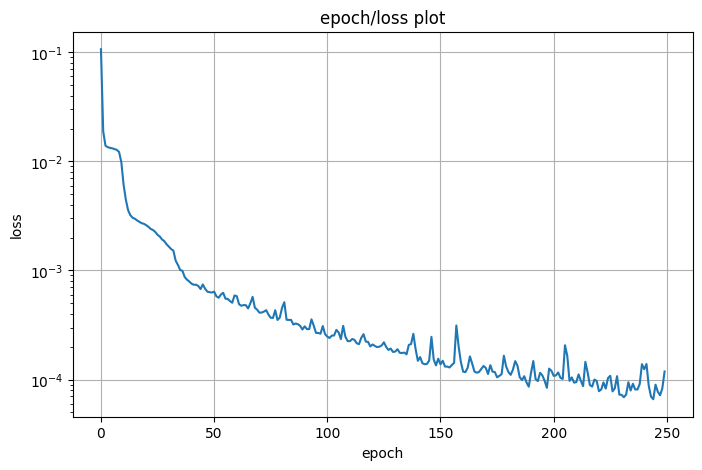

In [10]:
plt.figure(figsize=(8, 5))
# plt.plot(range(n_epochs), loss_history)
plt.semilogy(loss_history)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('epoch/loss plot')
plt.grid(True)
plt.show()

# Sobol coefficient

In [11]:
from SALib.sample import saltelli
from SALib.analyze import sobol

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

/tmp/ipykernel_79170/1394346549.py:12: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, 1024, calc_second_order=True)


sobol coeffs for Y_sw:
  feature        S1        ST   S1_conf   ST_conf
3      x3  0.003519  0.006588  0.005710  0.002372
4      x4  0.020941  0.042980  0.015718  0.007477
0      x0  0.073348  0.183107  0.034293  0.048488
1      x1  0.065687  0.199020  0.039931  0.045111
2      x2  0.665085  0.856957  0.114963  0.081378


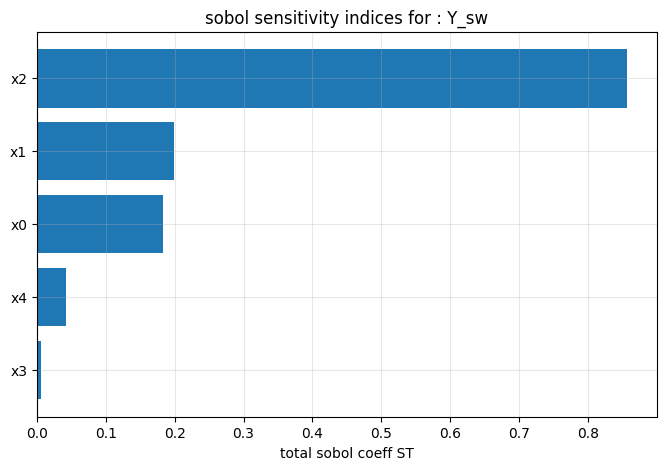

pairwise interactions S2 for  Y_sw
    x0        x1        x2        x3        x4
x0 NaN  0.012404  0.046644 -0.015539 -0.018543
x1 NaN       NaN  0.054582 -0.028482 -0.028252
x2 NaN       NaN       NaN  0.054549  0.063888
x3 NaN       NaN       NaN       NaN -0.004837
x4 NaN       NaN       NaN       NaN       NaN

----------------------------------------




sobol coeffs for Y_p:
  feature        S1        ST   S1_conf   ST_conf
3      x3  0.057139  0.097970  0.028009  0.012507
0      x0  0.095033  0.109164  0.025517  0.013998
1      x1  0.099475  0.115217  0.025483  0.014895
4      x4  0.222364  0.277183  0.040812  0.029328
2      x2  0.397958  0.505735  0.061481  0.061200


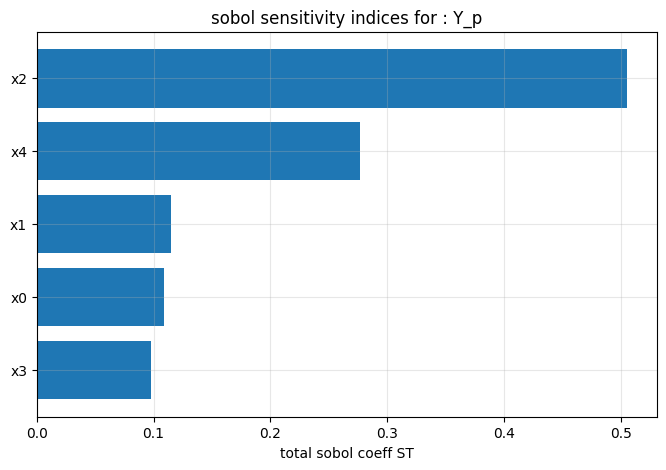

pairwise interactions S2 for  Y_p
    x0       x1        x2        x3        x4
x0 NaN  0.01006 -0.000304 -0.002296 -0.007024
x1 NaN      NaN  0.002150  0.000330  0.000815
x2 NaN      NaN       NaN  0.043545  0.064263
x3 NaN      NaN       NaN       NaN -0.008168
x4 NaN      NaN       NaN       NaN       NaN

----------------------------------------






In [13]:
X_data = torch.cat([xb for xb, yb in loader], dim=0)#.detach().cpu().numpy()
features = ['x'+str(i) for i in range(X_data.shape[1])]

problem = {
    'num_vars': X_data.shape[1],
    'names': features,
    'bounds': [
        [X_data[:, i].min(), X_data[:, i].max()]
        for i in range(X_data.shape[1])]
}

param_values = saltelli.sample(problem, 1024, calc_second_order=True)
X_sobol = torch.tensor(param_values, dtype=torch.float32).to(device)

model_net.eval()
with torch.no_grad():
    Y_pred = model_net(X_sobol).detach().cpu().numpy()

Y_sw = Y_pred[:, 0]
Y_p = Y_pred[:, 1]

for y_tpl in ((Y_sw, 'Y_sw'), (Y_p, 'Y_p')):
    Si = sobol.analyze(problem, y_tpl[0], calc_second_order=True)
    sobol_df = pd.DataFrame({
        'feature': problem['names'],
        'S1': Si['S1'],
        'ST': Si['ST'],
        'S1_conf': Si['S1_conf'],
        'ST_conf': Si['ST_conf']})
    sobol_df_sorted = sobol_df.sort_values('ST')
    print(f'sobol coeffs for {y_tpl[1]}:')
    print(sobol_df.sort_values('ST'))

    plt.figure(figsize=(8, 5))
    plt.barh(sobol_df_sorted['feature'], sobol_df_sorted['ST'])
    plt.xlabel('total sobol coeff ST')
    plt.title(f'sobol sensitivity indices for : {y_tpl[1]}')
    plt.grid(True, alpha=0.3)
    plt.show()

    print('pairwise interactions S2 for ', y_tpl[1])
    print(pd.DataFrame(
        Si['S2'],
        index=problem['names'],
        columns=problem['names']
    ))
    print('\n----------------------------------------\n\n\n\n')

In [14]:
Si

{'S1': array([0.09503326, 0.09947529, 0.39795818, 0.05713923, 0.22236402]),
 'S1_conf': array([0.02551692, 0.02548299, 0.06148087, 0.02800881, 0.04081206]),
 'ST': array([0.10916429, 0.11521704, 0.50573494, 0.09797039, 0.27718321]),
 'ST_conf': array([0.01399841, 0.01489468, 0.06119983, 0.01250723, 0.02932792]),
 'S2': array([[        nan,  0.01005977, -0.00030361, -0.0022956 , -0.00702416],
        [        nan,         nan,  0.00214964,  0.00032976,  0.00081482],
        [        nan,         nan,         nan,  0.04354472,  0.06426348],
        [        nan,         nan,         nan,         nan, -0.00816802],
        [        nan,         nan,         nan,         nan,         nan]]),
 'S2_conf': array([[       nan, 0.04901947, 0.04839193, 0.0457619 , 0.04549539],
        [       nan,        nan, 0.04572522, 0.04630046, 0.05048925],
        [       nan,        nan,        nan, 0.08748183, 0.08782857],
        [       nan,        nan,        nan,        nan, 0.04705429],
        [   

# Linear regression + Random Forest

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import seaborn as sns

In [16]:
X

array([[0.38333333, 0.98333335, 0.075     , 2.        , 2.        ],
       [0.01666667, 0.8833333 , 0.125     , 2.        , 2.        ],
       [0.5833333 , 0.35      , 0.95      , 2.        , 2.        ],
       ...,
       [0.55      , 0.9166667 , 0.        , 2.5       , 4.        ],
       [0.75      , 0.5833333 , 0.475     , 2.5       , 4.        ],
       [0.01666667, 0.25      , 0.8       , 2.5       , 4.        ]],
      shape=(150000, 5), dtype=float32)

In [17]:
Y

array([[0.2       , 0.18895245],
       [0.20017144, 0.21121709],
       [0.7189279 , 0.22043476],
       ...,
       [0.2       , 0.17301871],
       [0.57439137, 0.42910364],
       [0.66853654, 0.52180105]], shape=(150000, 2), dtype=float32)

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear) 
r2_linear = r2_score(y_test, y_pred_linear)


print('linear reg results:')
print('linear model coeffs: ', linear_model.coef_)
print('MAE: ', mae_linear)
print('MSE: ',mse_linear)
print('RMSE: ', rmse_linear)
print('R^2: ', r2_linear)

# RandomForestRegressor
print('RandomForestRegressor')

rf = RandomForestRegressor(
    random_state=42, 
    n_jobs=-1,
    n_estimators=100,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features=None,
    max_depth=10,
    bootstrap=True
)

# param_dist = {
#     'n_estimators': [100, 300, 500, 800],
#     'max_depth': [None, 5, 10, 15, 20, 30],
#     'min_samples_split': [2, 5, 10, 20],
#     'min_samples_leaf': [1, 2, 4, 8],
#     'max_features': [1, 2, 3, 'sqrt', None],
#     'bootstrap': [True, False],
# }
# search = RandomizedSearchCV(
#     estimator=rf,
#     param_distributions=param_dist,
#     n_iter=2,
#     cv=5,
#     scoring='neg_mean_squared_error',
#     random_state=42,
#     n_jobs=-1,
#     verbose=1
# )
# search.fit(X_train, y_train)
rf.fit(X_train, y_train)

# print('best params:', search.best_params_)
# best params: {'n_estimators': 500, 'min_samples_split': 20, 'min_samples_leaf': 8, 'max_features': None, 'max_depth': None, 'bootstrap': True}
# best params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 8, 'max_features': None, 'max_depth': 30, 'bootstrap': True}
# print('best CV score:', -search.best_score_)

random_forest_model = rf # search.best_estimator_


random_forest_model.fit(X_train, y_train)
y_pred_rf = random_forest_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print('random forest results:')
print('MAE: ', mean_absolute_error(y_test, y_pred_rf))
print('MSE: ',mean_squared_error(y_test, y_pred_rf))
print('RMSE: ', np.sqrt(mse_rf))
print('R^2: ', r2_score(y_test, y_pred_rf))

linear reg results:
linear model coeffs:  [[-0.11736062 -0.11809643  0.31329477  0.00698646 -0.03774936]
 [-0.13223417 -0.13193825  0.00207004  0.03762663  0.08998211]]
MAE:  0.06857657432556152
MSE:  0.008609730750322342
RMSE:  0.09278863481225673
R^2:  0.5154260993003845
RandomForestRegressor
random forest results:
MAE:  0.010914131244921216
MSE:  0.0003541554747416355
RMSE:  0.018819018963315687
R^2:  0.9777708118689903


## Sobol index 

/tmp/ipykernel_79170/3083993157.py:12: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, 1024, calc_second_order=True)


sobol coeffs for Y_sw:
  feature        S1        ST   S1_conf   ST_conf
3      x3  0.000000  0.000000  0.000000  0.000000
4      x4  0.000000  0.000000  0.000000  0.000000
0      x0  0.067693  0.183393  0.038979  0.043632
1      x1  0.072926  0.204006  0.045073  0.049347
2      x2  0.678961  0.878100  0.108871  0.072700


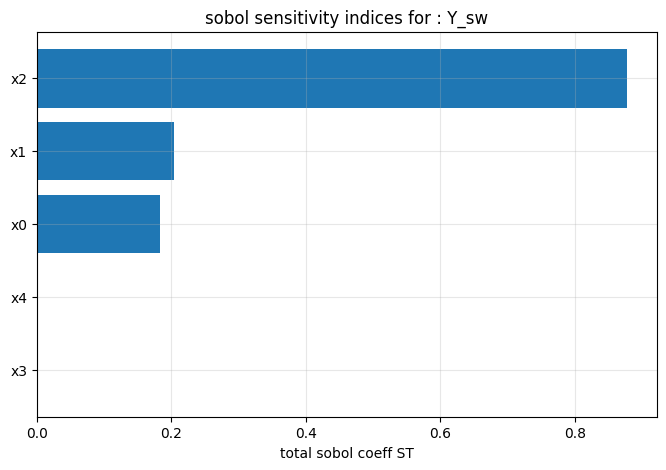

pairwise interactions S2 for  Y_sw
    x0        x1        x2        x3        x4
x0 NaN  0.022486  0.078719 -0.004278 -0.004278
x1 NaN       NaN  0.069246 -0.014910 -0.014910
x2 NaN       NaN       NaN  0.047476  0.047476
x3 NaN       NaN       NaN       NaN  0.000000
x4 NaN       NaN       NaN       NaN       NaN

----------------------------------------




sobol coeffs for Y_p:
  feature        S1        ST   S1_conf   ST_conf
3      x3  0.000000  0.000000  0.000000  0.000000
4      x4  0.000000  0.000000  0.000000  0.000000
0      x0  0.262218  0.327591  0.043472  0.033332
1      x1  0.273118  0.348471  0.046076  0.044220
2      x2  0.393219  0.420279  0.064928  0.042731


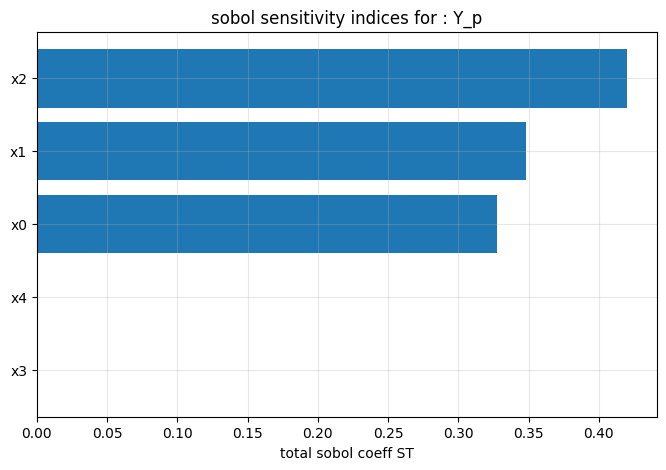

pairwise interactions S2 for  Y_p
    x0       x1        x2        x3        x4
x0 NaN  0.06351  0.017740 -0.001941 -0.001941
x1 NaN      NaN  0.028229  0.006699  0.006699
x2 NaN      NaN       NaN -0.002785 -0.002785
x3 NaN      NaN       NaN       NaN  0.000000
x4 NaN      NaN       NaN       NaN       NaN

----------------------------------------






In [22]:
X_data = torch.cat([xb for xb, yb in loader], dim=0)#.detach().cpu().numpy()
features = ['x'+str(i) for i in range(X_data.shape[1])]

problem = {
    'num_vars': X_data.shape[1],
    'names': features,
    'bounds': [
        [X_data[:, i].min(), X_data[:, i].max()]
        for i in range(X_data.shape[1])]
}

param_values = saltelli.sample(problem, 1024, calc_second_order=True)
X_sobol = torch.tensor(param_values, dtype=torch.float32).to(device)

# random_forest_model.eval()
# with torch.no_grad():
Y_pred = random_forest_model.predict(X_sobol)#.detach().cpu().numpy()

Y_sw = Y_pred[:, 0]
Y_p = Y_pred[:, 1]

for y_tpl in ((Y_sw, 'Y_sw'), (Y_p, 'Y_p')):
    Si = sobol.analyze(problem, y_tpl[0], calc_second_order=True)
    sobol_df = pd.DataFrame({
        'feature': problem['names'],
        'S1': Si['S1'],
        'ST': Si['ST'],
        'S1_conf': Si['S1_conf'],
        'ST_conf': Si['ST_conf']})
    sobol_df_sorted = sobol_df.sort_values('ST')
    print(f'sobol coeffs for {y_tpl[1]}:')
    print(sobol_df.sort_values('ST'))

    plt.figure(figsize=(8, 5))
    plt.barh(sobol_df_sorted['feature'], sobol_df_sorted['ST'])
    plt.xlabel('total sobol coeff ST')
    plt.title(f'sobol sensitivity indices for : {y_tpl[1]}')
    plt.grid(True, alpha=0.3)
    plt.show()

    print('pairwise interactions S2 for ', y_tpl[1])
    print(pd.DataFrame(
        Si['S2'],
        index=problem['names'],
        columns=problem['names']
    ))
    print('\n----------------------------------------\n\n\n\n')